## Intensity Distributions
___
Per-cell and pooled intensity distribution analysis.

In [1]:
import sys
from pathlib import Path
from microlive import microscopy as mi
one_drive_dir = mi.Utilities.get_one_drive_dir()
repo_root = Path().resolve().parents[1]  
sys.path.insert(0, str(repo_root))
import utilities 
from utilities import intensity_distributions as idist


## Data path & folder detection
___

In [2]:
dataframes_dir = one_drive_dir / 'General - Zhao (NZ) Lab' / 'Zhao lab shared folder' / 'Our papers' / 'co-translational folding paper' / 'Fig 1' / 'Fig 1_Trunc minitrack analysis'
#dataframes_dir = one_drive_dir / 'General - Zhao (NZ) Lab' / 'Zhao lab shared folder' / 'Our papers' / 'co-translational folding paper' / 'Fig 2' / 'Fig 2_4xGFP coTFT minitrack analysis'


In [3]:
current_dir = Path().resolve()
save_dir = current_dir / f'results_{dataframes_dir.name}'
save_dir.mkdir(parents=True, exist_ok=True)
print('Plots saved at:', save_dir)
list_folder_substrings, list_names = utilities.get_folder_substrings_and_names(dataframes_dir)
print('Substrings:', list_folder_substrings)
print('Names:', list_names)


Plots saved at: /Users/nzlab-la/Desktop/cof_paper/notebooks/CoF_project/results_Fig 1_Trunc minitrack analysis
Found 2 plasmids in 28 folders
  pNZ212: 1 experiment(s)
  pNZ405: 1 experiment(s)
Substrings: ['pNZ212', 'pNZ405']
Names: ['6sfGFP', '6xsfGFP (trunc)']


## Parameters
___

In [4]:
# ── Data & filtering ──────────────────────────────────────────────────────────
selected_field        = 'spot_int_ch_'   # column prefix
drop_nonpositive      = False            # False → keep negatives; True → drop ≤ 0

# ── Display mode ──────────────────────────────────────────────────────────────
# Mode 1: "mean per particle" — time-averaged intensity per particle (1 value
#         per particle). Removes frame-to-frame noise.
# Mode 2: "all timepoints" — every (particle × frame) measurement as an
#         independent sample. Preserves temporal fluctuations.
display_mode          = 1                # 1 = mean per particle | 2 = all timepoints

# ── Visualization toggles ────────────────────────────────────────────────────
show_individual_cells = False            # per-cell subplot grids
show_hist             = True             # density histogram behind KDE (pooled)
show_cell_summary     = True             # swarm + box plot (one point per cell)
cell_stat             = 'mean'           # 'mean' or 'median' per cell

# ── X-axis limits ─────────────────────────────────────────────────────────────
xlim_override         = None             # e.g. (-10, 1500) or None for auto
xlim_percentile_lo    = 0.5                # lower percentile (auto mode)
xlim_percentile_hi    = 99.5               # upper percentile (auto mode)

# ── KDE configuration ─────────────────────────────────────────────────────────
kde_bw_method         = 'scott'          # 'scott', 'silverman', or a float
kde_alpha             = 0.3              # fill alpha for overlapping distributions

# ── Figure sizes & colours ────────────────────────────────────────────────────
figsize_distributions = (4, 5)           # pooled KDE overlay
figsize_whisker       = (4, 5)           # cell-level swarm + box
list_colors           = ['gray', 'tab:orange']


## Per-cell & pooled distribution plots
___


══════ Channel 1 (Nascent Chain) ══════
  6sfGFP                          mean=283.37   median=271.87   std=138.67   n_cells=14
  6xsfGFP (trunc)                 mean=502.60   median=352.86   std=341.46   n_cells=14
  Mann-Whitney U: U=58.0, p=0.06953


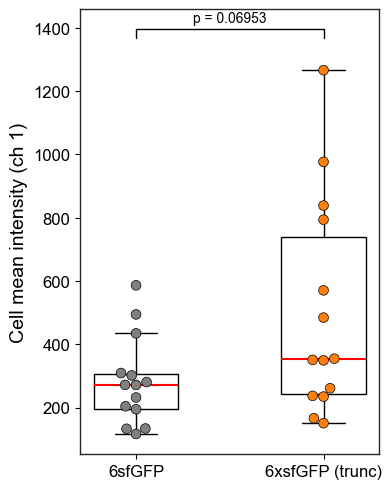

  6sfGFP                          mean=282.05   median=233.31   std=195.43   n=1444   n_cells=14
  6xsfGFP (trunc)                 mean=386.43   median=260.65   std=373.62   n=1494   n_cells=14


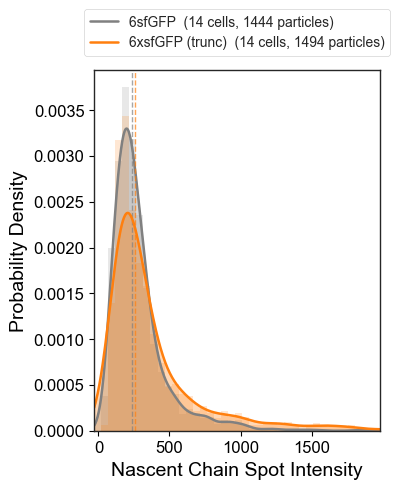


══════ Channel 0 (Folding) ══════
  6sfGFP                          mean=551.14   median=471.08   std=257.58   n_cells=14
  6xsfGFP (trunc)                 mean=163.73   median=113.84   std=111.08   n_cells=14
  Mann-Whitney U: U=186.0, p=5.809e-05


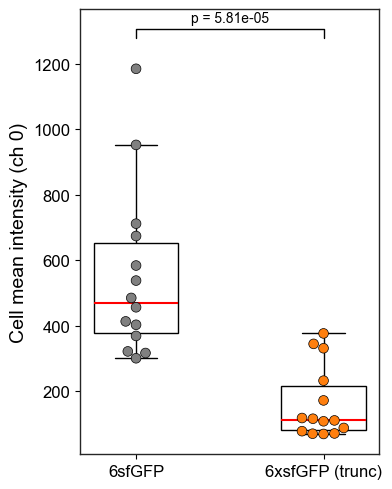

  6sfGFP                          mean=602.13   median=490.26   std=538.36   n=1444   n_cells=14
  6xsfGFP (trunc)                 mean=129.95   median=89.86   std=163.25   n=1494   n_cells=14


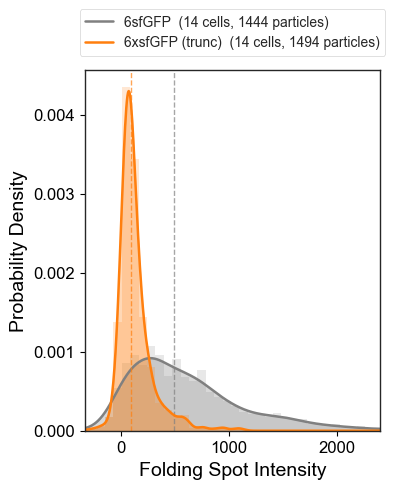

In [ ]:
xlim_pcts = (xlim_percentile_lo, xlim_percentile_hi)
for ch, ch_label in [(1, "Nascent Chain"), (0, "Folding")]:
    print(f"\n══════ Channel {ch} ({ch_label}) ══════")

    # Load data for this channel
    all_results_ch = []
    for folder_sub, name in zip(list_folder_substrings, list_names):
        r = idist.load_condition_intensities(dataframes_dir, folder_sub,selected_field=selected_field,channel_index=ch,drop_nonpositive=drop_nonpositive,)
        r["name"] = name
        all_results_ch.append(r)

    # Per-cell panels
    if show_individual_cells:
        for result, color in zip(all_results_ch, list_colors):
            idist.plot_per_cell_distributions(result, color=color, save_dir=save_dir,channel_index=ch, mode=display_mode,xlim=xlim_override, xlim_percentiles=xlim_pcts,
            kde_bw_method=kde_bw_method, kde_alpha=kde_alpha,drop_nonpositive=drop_nonpositive)
    # Cell-level summary (one point per cell, avoids pseudoreplication)
    if show_cell_summary:
        idist.plot_cell_summary(all_results_ch, list_colors, channel_index=ch,save_dir=save_dir, mode=display_mode,cell_stat=cell_stat,drop_nonpositive=drop_nonpositive,figsize=figsize_whisker, )

    # Pooled overlay
    idist.plot_pooled_distributions(all_results_ch, list_colors, channel_index=ch,x_label=f"{ch_label} Spot Intensity",
        save_dir=save_dir, mode=display_mode, xlim=xlim_override, xlim_percentiles=xlim_pcts, kde_bw_method=kde_bw_method, kde_alpha=kde_alpha,
        show_hist=show_hist,drop_nonpositive=drop_nonpositive,figsize=figsize_distributions,  )
